# Setup

In [1]:
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not Path("energy-climate-cookbook").exists():
        !git clone https://github.com/matteodefelice/energy-climate-cookbook.git
    %cd energy-climate-cookbook
    ! pip install pypsa

# Modelling

## Problem definition

An exmaple explores implications of long-term inflow dynamics for optimal design of a microgrid. Parameters of the model were specified using data from a real hydropower microgrid in Kisiizi, Uganda [Cartland et al 2023]. The microgrid consists of a hydroturbine, solar panels and diesel generator, and supplies power to commercial and domestic customers of Kisiizi sub-country. A model has been built using a 50-year long dataset of the inflow parameters taken from the GloFAS dataset [Harrigan et al 2023], which provides outputs from hydrological modelling forced by ERA5 reanalysis data.

We gratefully acknogledge Dr Davide Fioriti for helping out to shape design of this case-study according to the real development practice of off-grid systems.

### Import dependencies

In [2]:
import pandas as pd
# quick fix for PyPSA Arrow issue
pd.options.future.infer_string = False

import matplotlib.pyplot as plt
import pypsa

from pathlib import Path

E0000 00:00:1781645983.667535 318136881 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1781645983.667575 318136881 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1781645983.667577 318136881 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1781645983.667580 318136881 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1781645983.667581 318136881 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


# Prepare data

## Read input time-series
Input are stored in the `data` folder and contain data of meteorological factors and demand for about 50 years.

In [3]:
input_dir = "../data"
input_fl = "micro_grid_inputs.csv"

Read a pre-coompiled dataset and use its' first column as an index

In [4]:
inputs_full_df = pd.read_csv(Path(input_dir, input_fl), index_col=0)

Structure of the data input looks like follows:

In [5]:
inputs_full_df.head(5)

,inflow,ssrd,load
time,,,
1979-01-02 00:00:00,7.890625,0.0,237.254575
1979-01-02 01:00:00,7.875651,0.0,220.373665
1979-01-02 02:00:00,7.860677,0.0,222.213966
1979-01-02 03:00:00,7.845703,0.0,214.868724
1979-01-02 04:00:00,7.830729,0.0,205.222695


We transform the index into pandas `datetime` type to be able apply date-time transformations in further calculations:

In [6]:
inputs_full_df.index = pd.to_datetime(inputs_full_df.index)

### Creating inputs
  1. PV capacity factor is created using solar radiation and temperature as inputs
  2. Electricity demand and inflow values are loaded from the file

### Solar potential

Temperature data is extracted from the ERA5 dataset using the grid cell at the coordinates longitude 29.5 and latitude -1.25. We add then this dataset to the data frame that we have already loaded with the other inputs. 

In [7]:

tas_fl = "reanalysis-era5-single-levels-timeseries-sfc2umaigal.csv"
tas_df = pd.read_csv(Path(input_dir, tas_fl), index_col=0)
tas_df.index.name = "time"

#inputs_full_df["tas"] = tas_df["t2m"] - 273.15
inputs_full_df["tas"] = 30

We created a set of function stored in the file `conversion.py` to easily convert meteorological variables into energy variables

In [8]:
import conversion

Capacity factor of PV panel is determined by an actual value of solar irradiation and depends on air temperature:

In [9]:
solar_cf = conversion.pv_capacity_factor(
    G = inputs_full_df["ssrd"].values/3600, 
    T_air = inputs_full_df["tas"]._values, 
    gamma=-0.005, NOCT=45.0)
inputs_full_df["solar"] = solar_cf

Let's check the solar potential profile looks reasonable.

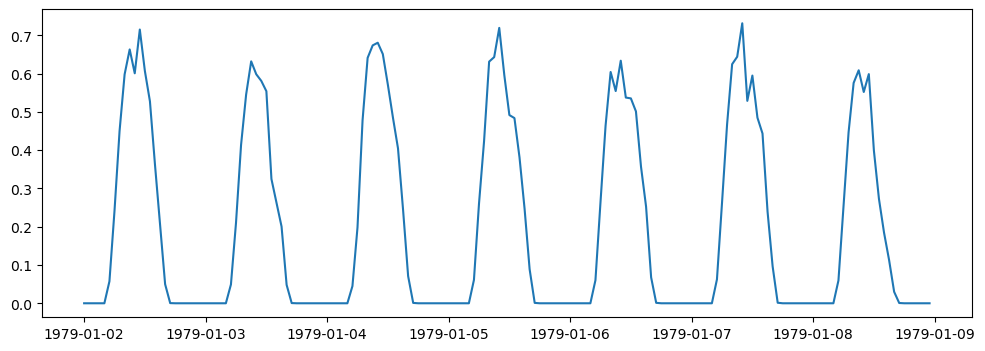

In [10]:
fig = plt.figure(figsize=(12, 4))
plt.plot(inputs_full_df["solar"][0:168])
plt.show()

### Load

Let's ensure the load data makes sense. Plotting is a quick way to to scan for anomalies.

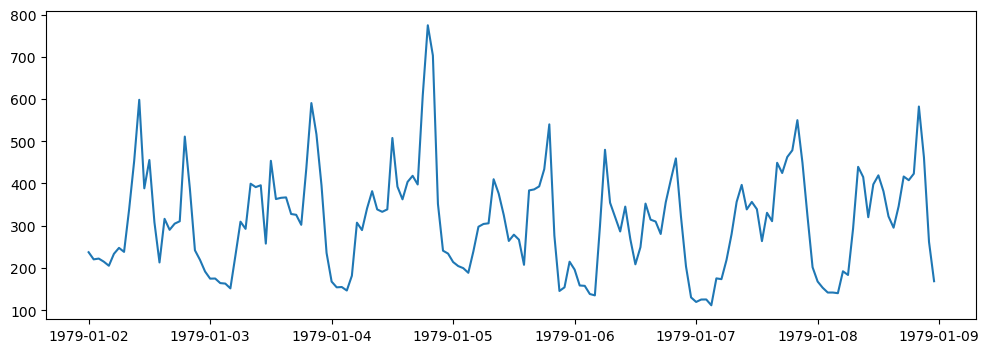

In [11]:
fig = plt.figure(figsize=(12, 4))
plt.plot(inputs_full_df["load"][0:168])
plt.show()

Check an annual profile for a single (rather arbitrary) year.

<Axes: xlabel='time'>

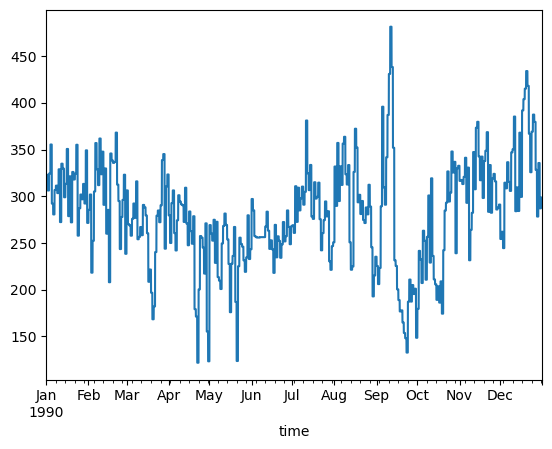

In [12]:
year_to_zoom_in = 1990
(
    inputs_full_df[inputs_full_df["load"].index.year == year_to_zoom_in]["load"]
    .groupby(inputs_full_df.index[inputs_full_df["load"].index.year == year_to_zoom_in].to_period("D"))
    .transform("mean")
    .plot()
)

## Multi-annual dynamics of inflow 

A quick graphic check of the inflow gives the following picture:

<Axes: xlabel='time'>

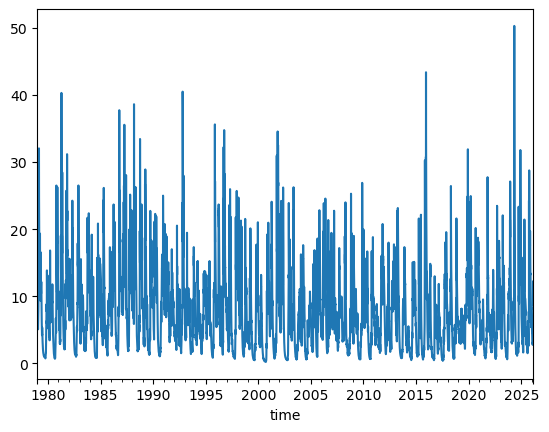

In [13]:
inputs_full_df["inflow"].plot()

To filter-out seasonal and multi-annual pattern, let's use averaging.

`"M"` is pandas code for monthly averaging.

In [14]:
inputs_full_df["inflow_monthly"] = (
    inputs_full_df["inflow"]
    .groupby(inputs_full_df.index.to_period("M"))
    .transform("mean")
)

`"Y"` stays for annual averaging.

In [15]:

inputs_full_df["inflow_ann"] = (
    inputs_full_df["inflow"]
    .groupby(inputs_full_df.index.to_period("Y"))
    .transform("mean")
)

Overlay changes on different time-scales. A dark-blue line gives a feeling for year-to-year changes in the inflow.

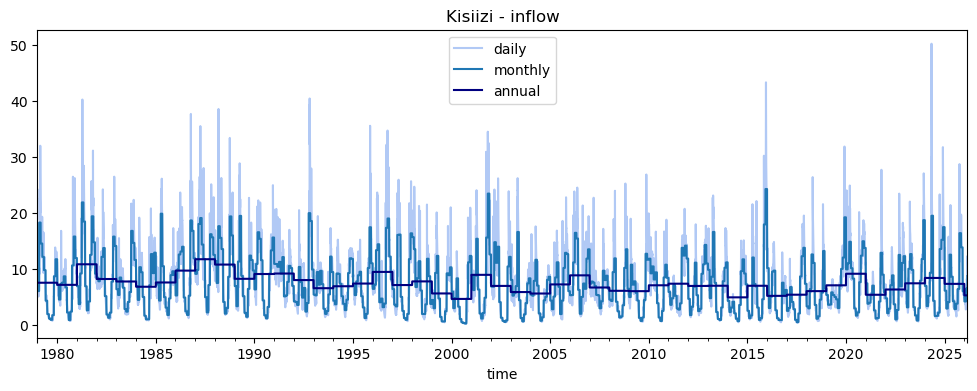

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
inputs_full_df["inflow"].plot(
    ax=ax, label="daily", alpha=0.5, color="cornflowerblue"
)
inputs_full_df["inflow_monthly"].plot(
    ax=ax, label="monthly"
)
inputs_full_df["inflow_ann"].plot(
    ax=ax, label="annual", color="navy"
)
ax.set_title("Kisiizi - inflow")
ax.legend()

Zoom-in into inflow profile for a single year to assess seasonaliy pattern.

Previously, we have transformed an index of `inputs_full_df` into `datatime` format. That makes it possible to use `year` for selecting a relevant part of the dataframe:

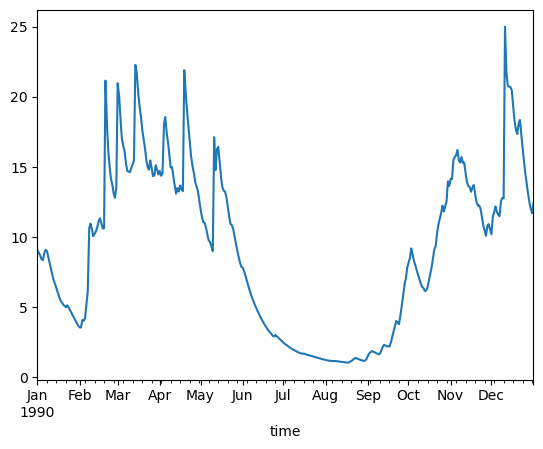

In [17]:
year_to_zoom_in = 1990
inflow_daily_single_year = (
    inputs_full_df[inputs_full_df["inflow"].index.year == year_to_zoom_in]["inflow"]
    .plot()
)

### Hydropotential

To use inflow data in energy system modelling, we need to transform them into hydro potential.

In [18]:
H = 3     # [m] water height
g = 9.81  # [m/s**2]
rho = 996 # [kg/m3] water density at 30C

PyPSA is using `MW` and `hour` as a default units of measurments.

In [19]:
inputs_full_df["hydro"] = (
    g * H * rho * (inputs_full_df["inflow"] / 1e3)
)

# Build network model

We will build a simple capacity expansion model of a micro-grid assuming that there is no pre-installed capacities. That is so called greenfield optimisation.

## Simple micro-grid model

PyPSA models are using values for capital costs which account for investment costs by using annualisation calculated for some specific discount rate and lifetime values for energy equipment.

Taking a discount rate at 5% and taking capital cost and lifetime values from PyPSA `technology-database` we get the following costs inputs to be used in modelling. 

In [20]:
solar_capital_cost=0.5 # EUR/MWel
hydro_capital_cost=1.0 # EUR/MWel
diesel_capital_cost=0.3 # EUR/MWel
fuel_cost=(0.70/1e3) # EUR/MWth

We will also need an extimation of energy-to-power ratio for a hydro energy storage. Let's assume a reservoir can store water for a day.

In [21]:
n_max_hours = 24 # hours

### Building microgrid model for a single year

#### Select a timespan

Let's build and optimise a microgrid model for (an arbitrary) 2025 year. That is the latest year available in GloFAS and ERA5 datasets.

In [22]:
inflow_2025 = inputs_full_df[inputs_full_df["inflow"].index.year == 2025]["inflow"].mean()
inflow_avr = inputs_full_df["inflow"].mean()

In [23]:
print(f"Average hourly inflow 2025:     {inflow_2025:.1f} m3/s")
print(f"Average hourly inflow 50 years: {inflow_avr:.1f} m3/s")

Average hourly inflow 2025:     7.3 m3/s
Average hourly inflow 50 years: 7.4 m3/s


Use filtering by `year` value for selecting a relevant part of the dataframe to be used as an input when building an energy model.

In [24]:
inputs_2025_df = inputs_full_df[inputs_full_df.index.year==2025]

#### Build energy system model

Let's create `Network` object with the time dimention `snapshots` corresponding to the index of the input dataframe.

In [25]:
microgrid_2025 = pypsa.Network(snapshots = inputs_2025_df.index)


Add a bus which is a generic node of the model to which all other compenents can be attached:

In [26]:
microgrid_2025.add("Bus", "B1")

Attach a load:

In [27]:
microgrid_2025.add("Load", "L1",
            bus="B1",
            carrier="el_demand",                
            p_set=inputs_2025_df["load"])

Add a PV generator assuming the annualised capital costs and allowing for capacity expansion.

In [28]:
microgrid_2025.add("Generator", "PV",
    carrier = "PV",
    bus="B1",
    capital_cost = solar_capital_cost,
    p_max_pu = inputs_2025_df["solar"],
    p_nom_extendable = True,
)

To model a hydro generator, we use `StorageUnit` component with `p_min_pu=0.0` which means that the unit can't consume power (that is can't work as pumped storage). The `inflow` argument requires inputs provided in power units [MW]. An argument `cyclic_state_of_charge=True` which forces the final state of charge to be set equal to the initial state of charge.

In [29]:
microgrid_2025.add("StorageUnit", "Hydro",
    bus="B1",
    carrier="Hydro",
    max_hours = n_max_hours,
    p_max_pu=1.0,  # dispatch
    p_min_pu=0.0,  # store
    capital_cost = hydro_capital_cost,
    inflow = inputs_2025_df["hydro"],       
    p_nom_extendable = True,
    efficiency_dispatch=0.9,
    efficiency_store=0.0,
    cyclic_state_of_charge=True,
)

We also add a diesel generator with fuel costs accounted by `marginal_cost` argument. The diesel generator is set extendable with `p_nom_extendable = True` to ensure that energy demand can be covered at any moment.

In [30]:
microgrid_2025.add("Generator", "Diesel",
    carrier = "Diesel",
    bus="B1",
    capital_cost = diesel_capital_cost,
    marginal_cost = fuel_cost,
    p_nom_extendable = True
)

### Prepare and solve network

`sanitize()` method is used to run consistency checks and apply technical fixes if needed.

In [31]:
microgrid_2025.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 5 missing carriers: ['AC', 'Diesel', 'Hydro', 'PV', 'el_demand']
INFO:pypsa.components._types.carriers:Assigned colors to 5 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


Let's start an optimisation run. `HiGHS` solver is used as a default and is included as one of PyPSA core dependencies.

In [32]:
microgrid_2025.optimize()

/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_56750/2077734884.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid_2025.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 323.24it/s]
INFO:linopy.io: Writing time: 0.19s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-p61xwaeu has 105123 rows; 52563 cols; 188639 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [7e-04, 1e+00]
  Bound   [4e+01, 8e+02]
  RHS     [3e+01, 9e+02]
Presolving model
44392 rows, 35635 cols, 110980 nonzeros  0s
Dependent equations search running on 13436 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
44392 rows, 35635 cols, 110980 nonzeros  0s
Presolve reductions: rows 44392(-60731); columns 35635(-16928); nonzeros 110980(-77659) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.1s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52563 primals, 105123 duals
Objective: 1.15e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


      38171     1.1507742559e+03 Pr: 0(0); Du: 0(4.15463e-14) 4.9s
      38171     1.1507742559e+03 Pr: 0(0); Du: 0(4.15463e-14) 4.9s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-p61xwaeu
Model status        : Optimal
Simplex   iterations: 38171
Objective value     :  1.1507742559e+03
P-D objective error :  2.0737227293e-15
HiGHS run time      :          5.00


('ok', 'optimal')

### Examine results

The easiest way to get an overview of the optimisation outputs is using `statistics()` method.

In [33]:
microgrid_2025.statistics()

Optimal Capacity  Installed Capacity        Supply  \
Generator   Diesel            642.05575                 0.0  6.556765e+05   
            PV                472.07538                 0.0  5.351761e+05   
Load        el_demand           0.00000                 0.0  0.000000e+00   
StorageUnit Hydro             263.14628                 0.0  1.265436e+06   

                         Withdrawal  Energy Balance Transmission  \
Generator   Diesel     0.000000e+00    6.556765e+05          0.0   
            PV         0.000000e+00    5.351761e+05          0.0   
Load        el_demand  2.456288e+06   -2.456288e+06          0.0   
StorageUnit Hydro      0.000000e+00    1.265436e+06          0.0   

                       Capacity Factor   Curtailment  Capital Expenditure  \
Generator   Diesel            0.116577  4.968732e+06            192.61672   
            PV                0.129414  2.456256e+05            236.03769   
Load        el_demand              NaN  0.000000e+00              0.00000   
StorageUnit Hydro             0.548957  1.039726e+06            263.14628   

                       Operational Expenditure     Revenue  Market Value  
Generator   Diesel                   458.97356   651.59028      0.000994  
            PV                         0.00000   236.03769      0.000441  
Load        el_demand                  0.00000 -1499.19229           NaN  
StorageUnit Hydro                      0.00000   611.56432      0.000483

It is possible to explote each of the arributes of `statistics` using a dedicated method:

In [34]:
microgrid_2025.statistics.energy_balance()

component    carrier    bus_carrier
Generator    Diesel     AC             6.556765e+05
             PV         AC             5.351761e+05
Load         el_demand  AC            -2.456288e+06
StorageUnit  Hydro      AC             1.265436e+06
dtype: float64

PyPSA has in-built plotting capabilities which can be convenient to get quick graphic representation of the results.

(<Figure size 411.111x400 with 1 Axes>,
 <Axes: xlabel='Optimal Capacity [MW]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x325e6d010>)

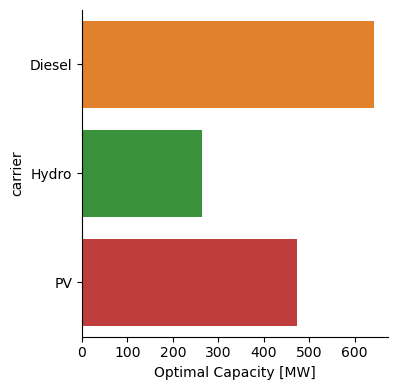

In [35]:
microgrid_2025.statistics.optimal_capacity.plot()

#### Customise plotting

Let's make plot even nicier using in-built customisation options. Default colors are defined by `n.carriers` dataframe:

In [36]:
microgrid_2025.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,
AC,0.0,#1f77b4,,inf,0.0
Diesel,0.0,#ff7f0e,,inf,0.0
Hydro,0.0,#2ca02c,,inf,0.0
PV,0.0,#d62728,,inf,0.0
el_demand,0.0,#9467bd,,inf,0.0


To update a color scheme used for plotting, we need to modify the colors. We will use the following dictionary to define a new set of colors for each of the carriers in the network:

In [37]:
power_color_dict = {
    "AC": "#8E6BBE",         # muted purple
    "Diesel": "gray",        # degault gray
    "el_demand": "#A65E4E",  # terracotta
    "Hydro": "#4DA3FF",      # soft blue
    "PV": "#FFB347",         # pastel orange
}
microgrid_2025.carriers["color"] = (
    microgrid_2025.carriers.index.to_series().map(power_color_dict)
)

Check an updated pallette:

In [38]:
microgrid_2025.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,
AC,0.0,#8E6BBE,,inf,0.0
Diesel,0.0,gray,,inf,0.0
Hydro,0.0,#4DA3FF,,inf,0.0
PV,0.0,#FFB347,,inf,0.0
el_demand,0.0,#A65E4E,,inf,0.0


Now the energy balance plot has slightly more meangful colors.

(<Figure size 411.111x400 with 1 Axes>,
 <Axes: xlabel='Optimal Capacity [MW]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x325551810>)

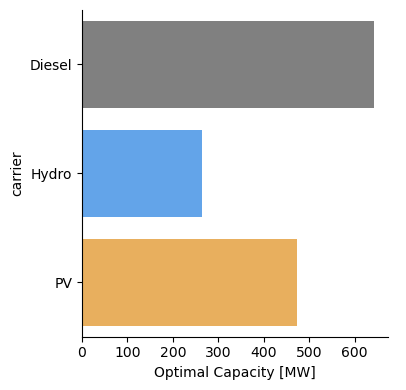

In [39]:
microgrid_2025.statistics.optimal_capacity.plot()

### Plotting dispatch

To plot dispatch, we'll work with the generation time-series extracted from the model.

In [40]:
dispatch_2025_hourly = pd.DataFrame({
    "PV": microgrid_2025.generators_t["p"]["PV"],
    "Diesel": microgrid_2025.generators_t["p"]["Diesel"],
    "Hydro": microgrid_2025.storage_units_t["p"]["Hydro"],
})
dispatch_2025 = dispatch_2025_hourly.resample("D").sum()

Stacked area plot can be used with the color schema defined previously by `power_color_dict` dictionary.

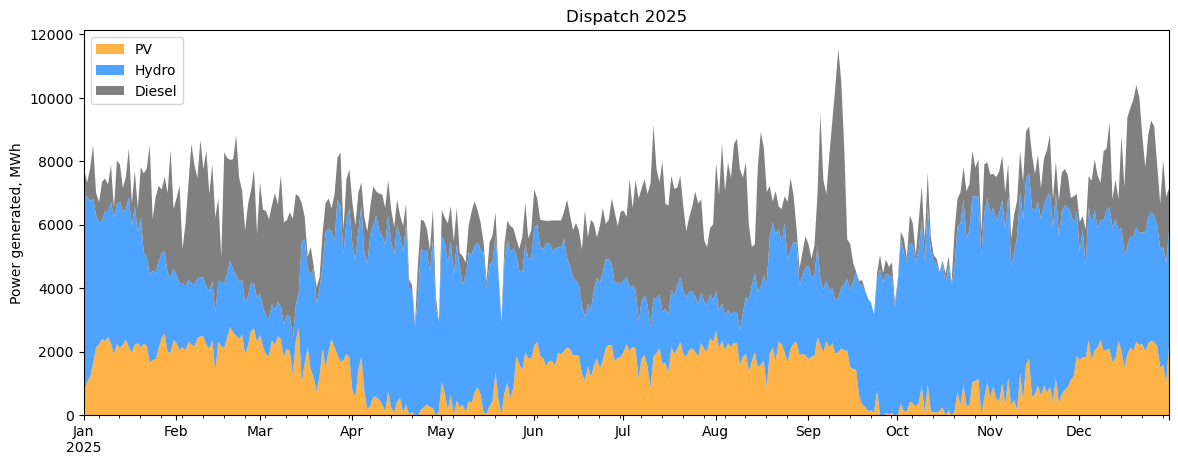

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))
dispatch_2025[["PV", "Hydro", "Diesel"]].plot.area(
    ax=ax,
    linewidth=0,
    color=power_color_dict,
)

ax.set_title("Dispatch 2025")
ax.set_xlabel("")
ax.set_ylabel("Power generated, MWh")
ax.legend(loc="best")

## Muliannual variability

Now, we will investigate an effect of year-to-year variations in the inflow on an optimal design of the micro-grid. To automate calculations, it is handy to define functions which build and plot a grid model. A set of such functions is stored in `pypsa_helpers.py` module which we'll use as a local import.

In [42]:
import pypsa_helpers

### Deterministic modelling

We need to selsect a few years to represent different hydrological conditions.

In [43]:
YEAR_avr = 2011 # average year
YEAR_dry = 2000 # dry year
YEAR_wet = 1991 # wet year

Check the inflow values for each of the selected years, and compare agains the long-term average.

In [44]:
inflow_mean_wet = inputs_full_df[inputs_full_df["inflow"].index.year == YEAR_wet]["inflow"].mean()
inflow_mean_avr = inputs_full_df[inputs_full_df["inflow"].index.year == YEAR_avr]["inflow"].mean()
inflow_mean_dry = inputs_full_df[inputs_full_df["inflow"].index.year == YEAR_dry]["inflow"].mean()

inflow_mean_mutliann = inputs_full_df["inflow"].mean()

In [45]:
print(f"Average hourly wet year:     {inflow_mean_wet:.1f} m3/s")
print(f"Average hourly average year: {inflow_mean_avr:.1f} m3/s")
print(f"Average hourly dry year:     {inflow_mean_dry:.1f} m3/s")
print("-------------------------------------")
print(f"Average hourly inflow 50 years: {inflow_mean_mutliann:.1f} m3/s")

Average hourly wet year:     9.2 m3/s
Average hourly average year: 7.4 m3/s
Average hourly dry year:     4.7 m3/s
-------------------------------------
Average hourly inflow 50 years: 7.4 m3/s


Select subset of inputs for each of the years.

In [46]:
inputs_avr_df =(
    pypsa_helpers.extract_year(merged_df=inputs_full_df, year=YEAR_avr)
    .set_index("time")
)
inputs_dry_df =(
    pypsa_helpers.extract_year(merged_df=inputs_full_df, year=YEAR_dry)
    .set_index("time")
)
inputs_wet_df =(
    pypsa_helpers.extract_year(merged_df=inputs_full_df, year=YEAR_wet)
    .set_index("time")
)

Build a microgrid model for each year. The cost values and all the components are defined in `pypsa_helpers` and are the same as we have used in a modelling example for a single year.

In [47]:
microgrid_avr = (
    pypsa_helpers.build_microgrid(df=inputs_avr_df)
)
microgrid_dry = (
    pypsa_helpers.build_microgrid(df=inputs_dry_df)
)
microgrid_wet = (
    pypsa_helpers.build_microgrid(df=inputs_wet_df)
)

Check consistency of each model and fix all the issues found.

In [48]:
microgrid_avr.sanitize()
microgrid_dry.sanitize()
microgrid_wet.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 7 missing carriers: ['AC', 'battery', 'diesel', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 7 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 7 missing carriers: ['AC', 'battery', 'diesel', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 7 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 7 missing carriers: ['AC', 'battery', 'diesel', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 7 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


Optimise all three models using `HiGHS` solver with default settings.

In [49]:
microgrid_avr.optimize()
microgrid_dry.optimize()
microgrid_wet.optimize()

/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_56750/4156161434.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid_avr.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 299.73it/s]
INFO:linopy.io: Writing time: 0.16s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-eco8acxj has 183965 rows; 87605 cols; 355079 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e-04, 1e+05]
  Bound   [5e+01, 6e+02]
  RHS     [3e+01, 9e+02]
Presolving model
83514 rows, 74758 cols, 233022 nonzeros  0s
Dependent equations search running on 26280 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
83514 rows, 74758 cols, 233022 nonzeros  0s
Presolve reductions: rows 83514(-100451); columns 74758(-12847); nonzeros 233022(-122057) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 17520(2.15444e+07) 0.3s
      27715     9.5935456587e+02 Pr: 8769(2.93306e+06); Du: 0(4.45836e-07) 5.5s
      37345     1.1565992052e+03 Pr: 286(312.313); Du: 0(5.66061e-07) 10.5s
      40786     7.6306842534e+02 Pr: 0

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87605 primals, 183965 duals
Objective: 7.25e+02
Solver model: available
Solver message: Optimal



      51080     7.2452125250e+02 Pr: 0(0) 34.5s
      51080     7.2452125250e+02 Pr: 0(0) 34.5s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-eco8acxj
Model status        : Optimal
Simplex   iterations: 51080
Objective value     :  7.2452125250e+02
P-D objective error :  8.7026683311e-15
HiGHS run time      :         34.67


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_56750/4156161434.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid_dry.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 264.01it/s]
INFO:linopy.io: Writing time: 0.16s


...

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-13646ni_ has 183965 rows; 87605 cols; 355079 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [5e-04, 1e+05]
  Bound   [9e+01, 6e+02]
  RHS     [3e+01, 9e+02]
Presolving model
83514 rows, 74758 cols, 233022 nonzeros  0s
Dependent equations search running on 26280 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
83514 rows, 74758 cols, 233022 nonzeros  0s
Presolve reductions: rows 83514(-100451); columns 74758(-12847); nonzeros 233022(-122057) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 17520(2.20117e+07) 0.3s
      32084     1.1173300185e+03 Pr: 6153(1.37147e+06); Du: 0(7.61677e-07) 5.4s
      37341     7.0673143547e+02 Pr: 0(0); Du: 690(1.03098) 10.7s
      40358     6.8989442784e+02 Pr: 0(0); Du: 9

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87605 primals, 183965 duals
Objective: 6.56e+02
Solver model: available
Solver message: Optimal



      45997     6.5621953865e+02 Pr: 0(0); Du: 0(2.43781e-14) 24.7s
      45997     6.5621953865e+02 Pr: 0(0); Du: 0(2.43781e-14) 24.7s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-13646ni_
Model status        : Optimal
Simplex   iterations: 45997
Objective value     :  6.5621953865e+02
P-D objective error :  1.2550708864e-14
HiGHS run time      :         24.81


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Compare dispatch time-series across years with different hydrological conditions.

(<Figure size 1400x1200 with 3 Axes>,
 array([<Axes: title={'center': 'Wet year'}, ylabel='Power'>,
        <Axes: title={'center': 'Average year'}, ylabel='Power'>,
        <Axes: title={'center': 'Dry year'}, xlabel='Time', ylabel='Power'>],
       dtype=object))

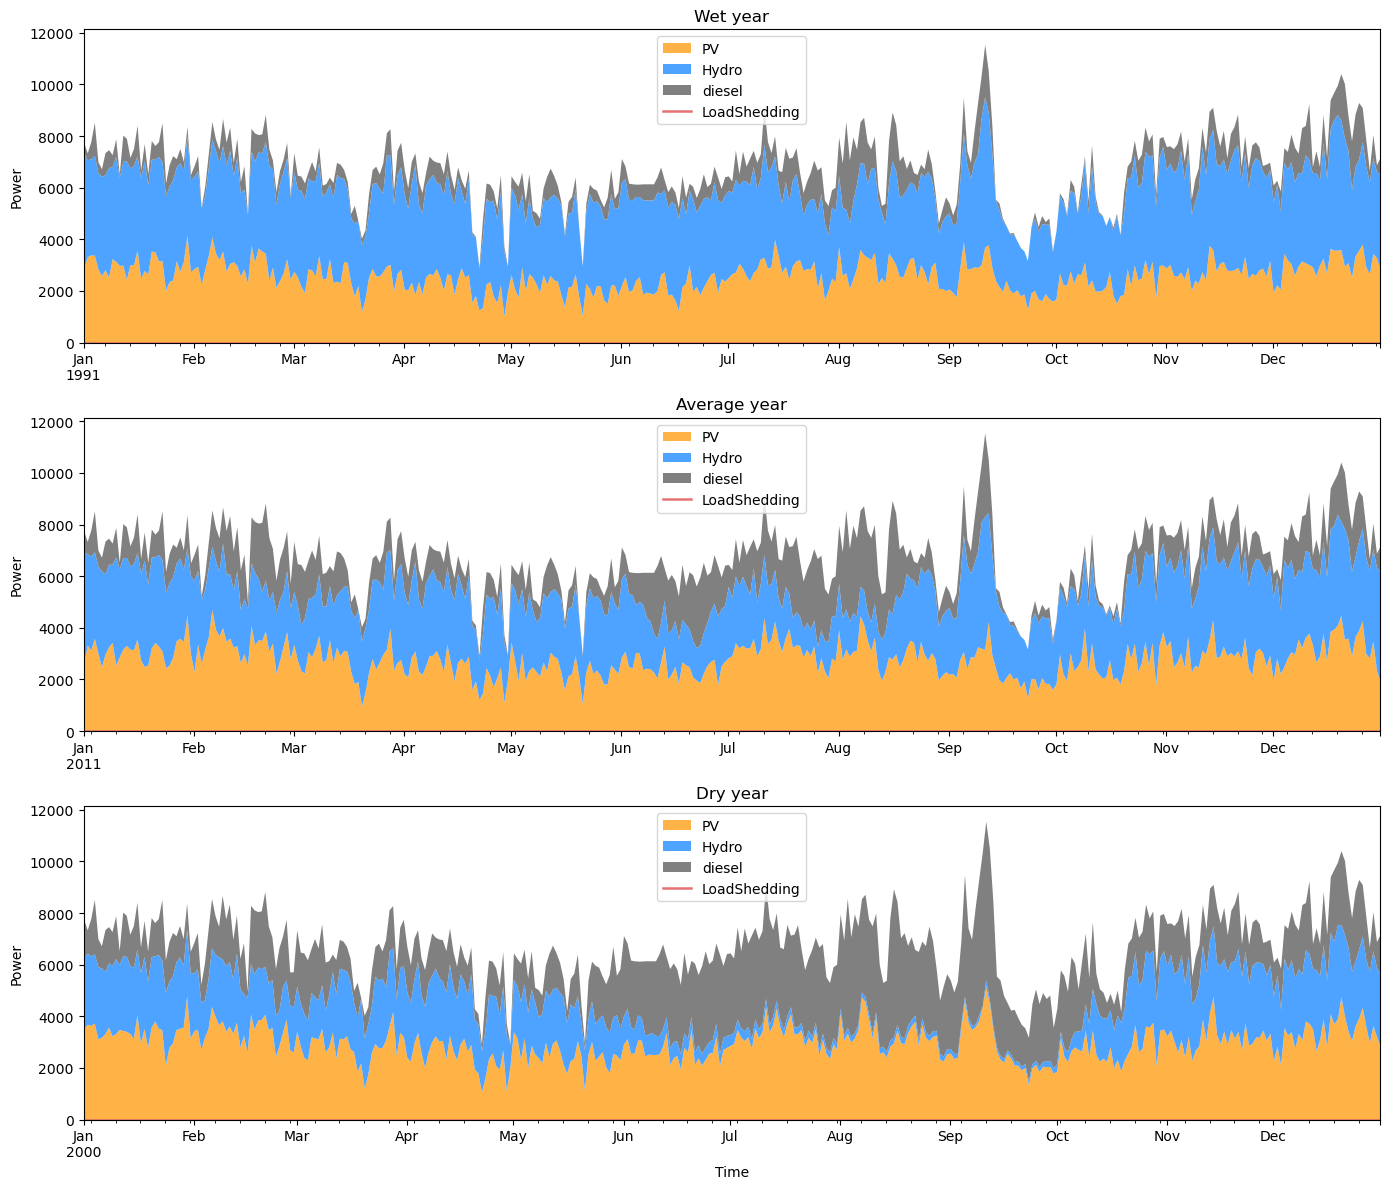

In [50]:
pypsa_helpers.plot_microgrid_facets(
    networks=[microgrid_wet, microgrid_avr, microgrid_dry],
    titles=["Wet year", "Average year", "Dry year", ]
)

## Stochastic modelling

Stochastic modelling allows to accommodate knowledge about existing uncertainties into a model. In our example, the major uncertainties are linked with hydrological scenarios.

### Estimating scenarios inputs

Let's estimate the difference between a "dry" and an "average" year.

In [51]:
HYDRO_DECREASE = (
    inputs_full_df[inputs_full_df.index.year==YEAR_dry]["hydro"].mean() / 
    inputs_full_df[inputs_full_df.index.year==YEAR_avr]["hydro"].mean()
)

### Hydro-solar connections

Our power system includes also a solar generator which share is quite high in an optimally designed system. That means we'll need to account for the solar potential when building scenarios.

Strictly speaking, inflow and solar irradiation aren't completelly independent since they are effected by atmospheric processes in the same place. Let's do a simple check what this connection looks like for the selected modelling location.

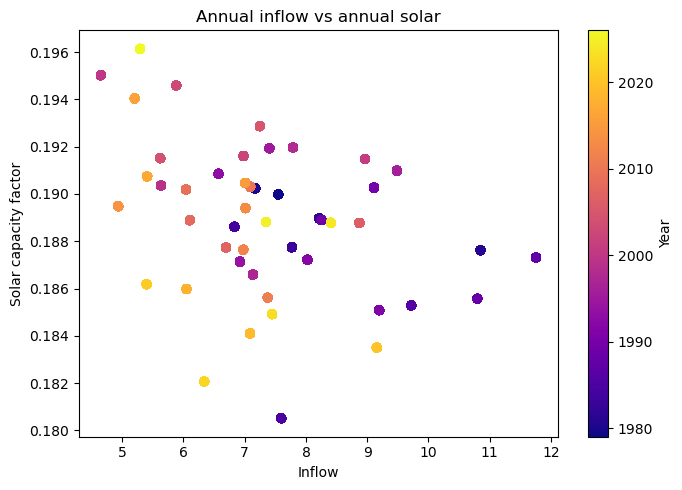

In [52]:
inputs_full_df["solar_ann"] = (
    inputs_full_df["solar"]
    .groupby(inputs_full_df.index.to_period("Y"))
    .transform("mean")
)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    x=inputs_full_df["inflow_ann"],
    y=inputs_full_df["solar_ann"],
    c=inputs_full_df.index.year,
    cmap="plasma",
)

ax.set_xlabel("Inflow")
ax.set_ylabel("Solar capacity factor")
ax.set_title("Annual inflow vs annual solar")

fig.colorbar(sc, ax=ax, label="Year")

plt.tight_layout()

We see that wetter years tend to have lower solar potential and visa versa. To keep our scenarios more realistic, we will also account for this effect.

In [53]:
SOLAR_INCREASE = (
    inputs_full_df[inputs_full_df.index.year==YEAR_dry]["solar"].mean() / 
    inputs_full_df[inputs_full_df.index.year==YEAR_avr]["solar"].mean()
)

### Building grid model

To use stochastic modelling, we will first define a micro-grid model exactly in a way we have done previously. The weather inputs correspond to the "average" year.

In [54]:
microgrid_scenarios = (
    pypsa_helpers.build_microgrid(
        df=inputs_avr_df,
    )
)

To set-up a two-stage stochastic model, we use `set_scenarios` method and define probabilities for each of the considered scenario. We will consider `dry`, `normal` and `wet` scenarios. For each of them, time-series must of the hydro and solar potential must be specified accordingly.

For the `normal` scenario, we keep the time-series, and apply scalings for `dry` and `wet` scenarios modifying `storage_units_t.inflow` and `generators_t.p_max_pu` for hydro and solar potential, respectivelly.

In [55]:
microgrid_scenarios.set_scenarios({"dry": 0.20, "normal": 0.50, "wet": 0.30})

microgrid_scenarios.storage_units_t.inflow.loc[:, ("dry", "Hydro")] *= HYDRO_DECREASE
microgrid_scenarios.generators_t.p_max_pu.loc[:, ("dry", "PV")] *= SOLAR_INCREASE

microgrid_scenarios.storage_units_t.inflow.loc[:, ("wet", "Hydro")] *= (1 + HYDRO_DECREASE)
microgrid_scenarios.generators_t.p_max_pu.loc[:, ("wet", "PV")] *= (1 - (SOLAR_INCREASE - 1))

Stochastic optimisation can be run using just the same methods as deterministic optimisation.

In [56]:
microgrid_scenarios.sanitize()
microgrid_scenarios.optimize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 7 missing carriers: ['AC', 'battery', 'diesel', 'el_demand', 'hydro', 'shedding', 'solar']
INFO:pypsa.components._types.carriers:Assigned colors to 7 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
/var/folders/qn/vpndfm21795ckkq89np1ckp40000gn/T/ipykernel_56750/2229447860.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  microgrid_scenarios.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 228.53it/s]
INFO:linopy.io: Writing time: 0.24s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-plh55i19 has 551895 rows; 262805 cols; 1065237 nonzeros
Coefficient ranges:
  Matrix  [2e-05, 2e+01]
  Cost    [1e-04, 5e+04]
  Bound   [3e+01, 1e+03]
  RHS     [3e+01, 1e+03]
Presolving model
250542 rows, 224266 cols, 699066 nonzeros  0s
Dependent equations search running on 78840 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
250542 rows, 224266 cols, 699066 nonzeros  0s
Presolve reductions: rows 250542(-301353); columns 224266(-38539); nonzeros 699066(-366171) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 52560(2.12299e+07) 0.8s
      48696     4.3092409173e+02 Pr: 43373(2.66539e+06); Du: 0(1.81093e-05) 5.9s
      55793     4.4430884803e+02 Pr: 39814(4.05207e+06); Du: 0(2.30533e-05) 11.4s
      60331     4.55058

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262805 primals, 551895 duals
Objective: 7.24e+02
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-plh55i19
Model status        : Optimal
Simplex   iterations: 149470
Objective value     :  7.2404403185e+02
P-D objective error :  1.5455449253e-14
HiGHS run time      :        148.77


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Nwtwork statistics contains now results for each of the considered scenarios. Outputs of the investment optimisations are the same for each of the scenarios. the outputs of dispatch modelling reflect effect of different weather conditions.

In [57]:
microgrid_scenarios.statistics()

Optimal Capacity  Installed Capacity  \
Generator   dry    diesel            640.17086                 0.0   
                   solar            1145.70744                 0.0   
            normal diesel            640.17086                 0.0   
                   solar            1145.70744                 0.0   
            wet    diesel            640.17086                 0.0   
                   solar            1145.70744                 0.0   
Load        dry    el_demand           0.00000                 0.0   
            normal el_demand           0.00000                 0.0   
            wet    el_demand           0.00000                 0.0   
StorageUnit dry    hydro             265.03117                 0.0   
            normal hydro             265.03117                 0.0   
            wet    hydro             265.03117                 0.0   

                                    Supply    Withdrawal  Energy Balance  \
Generator   dry    diesel     5.816124e+05  0.000000e+00    5.816124e+05   
                   solar      1.020211e+06  0.000000e+00    1.020211e+06   
            normal diesel     4.433188e+05  0.000000e+00    4.433188e+05   
                   solar      9.778599e+05  0.000000e+00    9.778599e+05   
            wet    diesel     3.476157e+05  0.000000e+00    3.476157e+05   
                   solar      8.104706e+05  0.000000e+00    8.104706e+05   
Load        dry    el_demand  0.000000e+00  2.456288e+06   -2.456288e+06   
            normal el_demand  0.000000e+00  2.456288e+06   -2.456288e+06   
            wet    el_demand  0.000000e+00  2.456288e+06   -2.456288e+06   
StorageUnit dry    hydro      8.544648e+05  0.000000e+00    8.544648e+05   
            normal hydro      1.035109e+06  0.000000e+00    1.035109e+06   
            wet    hydro      1.298202e+06  0.000000e+00    1.298202e+06   

                             Transmission  Capacity Factor   Curtailment  \
Generator   dry    diesel             0.0         0.103713  5.026284e+06   
                   solar              0.0         0.101651  9.371018e+05   
            normal diesel             0.0         0.079053  5.164578e+06   
                   solar              0.0         0.097431  8.850094e+05   
            wet    diesel             0.0         0.061987  5.260281e+06   
                   solar              0.0         0.080753  9.579552e+05   
Load        dry    el_demand          0.0              NaN  0.000000e+00   
            normal el_demand          0.0              NaN  0.000000e+00   
            wet    el_demand          0.0              NaN  0.000000e+00   
StorageUnit dry    hydro              0.0         0.368038  1.467208e+06   
            normal hydro              0.0         0.445846  1.286564e+06   
            wet    hydro              0.0         0.559166  1.023471e+06   

                              Capital Expenditure  Operational Expenditure  \
Generator   dry    diesel               192.05126                290.80619   
                   solar                 45.82830                  0.00000   
            normal diesel               192.05126                221.65941   
                   solar                 45.82830                  0.00000   
            wet    diesel               192.05126                173.80787   
                   solar                 45.82830                  0.00000   
Load        dry    el_demand              0.00000                  0.00000   
            normal el_demand              0.00000                  0.00000   
            wet    el_demand              0.00000                  0.00000   
StorageUnit dry    hydro                265.03117                  0.00000   
            normal hydro                265.03117                  0.00000   
            wet    hydro                265.03117                  0.00000   

                                Revenue  Market Value  
Generator   dry    diesel      58.16124      0.000100  
              

To compare results of stochastic modelling with deterministic runs, we need to do some post-processing. For deterministic models `microgrid_wet`, `microgrid_avr`, `microgrid_dry`, the optimal capacity can be extracted in a convenient form using the following transformation.

In [58]:
optimal_capacity_sens_long = pd.concat(
    [
        n.statistics.optimal_capacity().droplevel("component")
        for n in [microgrid_wet, microgrid_avr, microgrid_dry]
    ],
    keys=["Wet year", "Average year", "Dry year"],
    names=["weather year", "asset"],
).reset_index(name="opt_capacity_MW")

Wide data format is more convenient for visual inspection.

In [59]:
optimal_capacity_sens_wide = (
    optimal_capacity_sens_long
    .pivot(index="weather year", columns="asset", values="opt_capacity_MW")
)

Optimal capacity for deterministic models looks as follows.

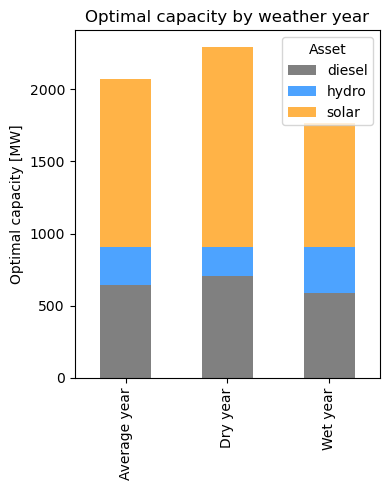

In [60]:
fig, ax = plt.subplots(figsize=(4, 5))

optimal_capacity_sens_wide.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color={
        "solar": "#FFB347",
        "hydro": "#4DA3FF",
        "diesel": "gray",
        "battery": "#9B7EDE",
    }
)

ax.set_xlabel("")
ax.set_ylabel("Optimal capacity [MW]")
ax.set_title("Optimal capacity by weather year")
ax.legend(title="Asset")

plt.tight_layout()

In [61]:
optimal_capacity_sens_wide

asset,diesel,hydro,solar
weather year,,,
Average year,645.72019,259.48184,1165.22654
Dry year,708.18616,197.01587,1389.96375
Wet year,586.66518,318.53685,862.11282


For the stochastic model, the output looks like that:

In [62]:
microgrid_scenarios.statistics.optimal_capacity()

component    scenario  carrier
Generator    dry       diesel      640.17086
                       solar      1145.70744
             normal    diesel      640.17086
                       solar      1145.70744
             wet       diesel      640.17086
                       solar      1145.70744
StorageUnit  dry       hydro       265.03117
             normal    hydro       265.03117
             wet       hydro       265.03117
dtype: float64

#### Energy balance

Outputs for the energy balance can be extracted using the same data transformations. For the deterministic models we have the following routine

In [63]:
energy_balance_sens_long = pd.concat(
    [
        n.statistics.energy_balance().droplevel("component").droplevel("bus_carrier")
        for n in [microgrid_wet, microgrid_avr, microgrid_dry]
    ],
    keys=["microgrid_wet", "microgrid_avr", "microgrid_dry"],
    names=["weather year", "asset"],
).reset_index(name="energy_balance_MWh")

In [64]:
energy_balance_sens_wide = (
    energy_balance_sens_long
    .pivot(index="weather year", columns="asset", values="energy_balance_MWh")
)

In [65]:
energy_balance_sens_wide

asset,diesel,el_demand,hydro,solar
weather year,,,,
microgrid_avr,449428.59294,-2.456288e+06,9.816435e+05,1.025216e+06
microgrid_dry,767202.37990,-2.462010e+06,5.992437e+05,1.095563e+06
microgrid_wet,254397.24385,-2.456288e+06,1.252583e+06,9.493079e+05


A barpolt allows for a visual a comparison across the energy balance for different weather years in a deterministic version of the model

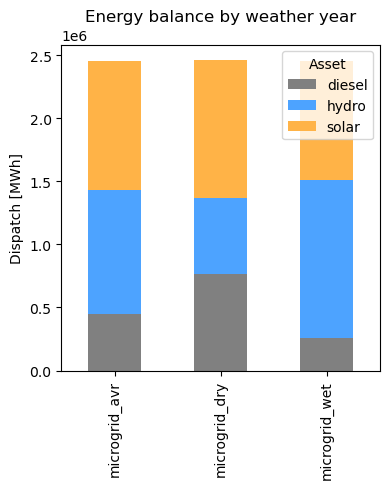

In [66]:
fig, ax = plt.subplots(figsize=(4, 5))

(
    energy_balance_sens_wide[["diesel", "hydro", "solar"]]
        .plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color={
            "solar": "#FFB347",
            "hydro": "#4DA3FF",
            "diesel": "gray",
            "battery": "#9B7EDE",
        }
    )
)

ax.set_xlabel("")
ax.set_ylabel("Dispatch [MWh]")
ax.set_title("Energy balance by weather year")
ax.legend(title="Asset")

plt.tight_layout()

Let's extract the energy balance from the stochastic model.

In [67]:
energy_balance_stats = (
    microgrid_scenarios.statistics()["Energy Balance"]
    .rename("Energy Balance")
    .reset_index()
)
energy_balance_stats.columns = ["component", "weather year", "asset", "Energy Balance"]
energy_balance_stats_wide = (
    energy_balance_stats
    .pivot_table(
        index="weather year",
        columns="asset",
        values="Energy Balance",
        aggfunc="sum",
    )
)

Similerly, the wide data format is more convenient.

In [68]:
energy_balance_stats_wide = energy_balance_stats_wide.rename(
    index={
        "normal": "Scenario Normal",
        "dry": "Scenario Dry",
        "wet": "Scenario Wet",
    }
)

Build a joined dataframe for deterministic `energy_balance_sens_wide` and stochastic `energy_balance_stats_wide` models for facilitate comparison.

In [69]:
combined_energy_balance = pd.concat(
    [
        energy_balance_sens_wide,
        energy_balance_stats_wide,
    ],
    axis=0,
)

Plot bar diagram alongside for deterministic and stochastic modelling to showcate the difference in the optimal energy generation mix.

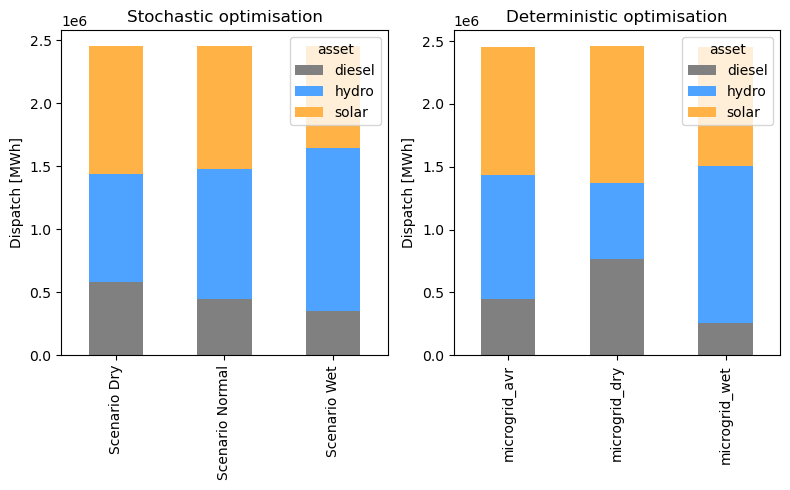

In [70]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 5)
)
(
    energy_balance_stats_wide[["diesel", "hydro", "solar"]]
    .plot(
        kind="bar",
        stacked=True,
        ax=axes[0],
        color={
            "solar": "#FFB347",
            "hydro": "#4DA3FF",
            "diesel": "gray",
            "battery": "#9B7EDE",
        }
    )
)
(
    energy_balance_sens_wide[["diesel", "hydro", "solar"]]
    .plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color={
            "solar": "#FFB347",
            "hydro": "#4DA3FF",
            "diesel": "gray",
            "battery": "#9B7EDE",
        }
    )
)

axes[0].set_title("Stochastic optimisation")
axes[0].set_xlabel("")
axes[0].set_ylabel("Dispatch [MWh]")
axes[0].tick_params(axis="x", rotation=90)

axes[1].set_title("Deterministic optimisation")
axes[1].set_xlabel("")
axes[1].set_ylabel("Dispatch [MWh]")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()

Let's compare overall costs across scenarios. `objective` contains information about all the costs of energy supply and can be used for a quick comparison.

In [71]:
print(f"Probablistic: {microgrid_scenarios.objective:.0f} EUR")
print(f"----------------------")
print(f"Wet year:     {microgrid_wet.objective:.0f} EUR")
print(f"Average year: {microgrid_avr.objective:.0f} EUR")
print(f"Dry year:     {microgrid_dry.objective:.0f} EUR")

Probablistic: 724 EUR
----------------------
Wet year:     656 EUR
Average year: 725 EUR
Dry year:     849 EUR
